In [ ]:
!pip install -q tensorflow==2.19.0
!pip install -q git+https://github.com/openai/CLIP.git
!pip install -q imageio tqdm

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.2 MB/s eta 0:00:00


In [ ]:
import os, sys, numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from PIL import Image
import cv2
from tqdm import tqdm
import random
import clip
import torch

print("TF", tf.__version__)
device = "cuda" if torch.cuda.is_available() else "cpu"
model_clip, preprocess_clip = clip.load("ViT-B/32", device=device)


TF 2.19.0


100%|████████████████████████████████████████| 338M/338M [00:02<00:00, 138MiB/s]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
BASE="/content/drive/MyDrive/corneal_ulcer_dataset"
train_images = np.load(os.path.join(BASE, "train_images.npy"))
train_ulcer  = np.load(os.path.join(BASE, "train_ulcer.npy"))
val_images   = np.load(os.path.join(BASE, "val_images.npy"))
val_ulcer    = np.load(os.path.join(BASE, "val_ulcer.npy"))
test_images  = np.load(os.path.join(BASE, "test_images.npy"))
test_ulcer   = np.load(os.path.join(BASE, "test_ulcer.npy"))

# Ensuring shapes
def ensure_mask_shape(m):
  if m.ndim==3:
    return np.expand_dims(m, -1)
  return m

train_ulcer = ensure_mask_shape(train_ulcer).astype(np.uint8)
val_ulcer   = ensure_mask_shape(val_ulcer).astype(np.uint8)
test_ulcer  = ensure_mask_shape(test_ulcer).astype(np.uint8)
print("Train images:", train_images.shape)
print("Train masks:", train_ulcer.shape)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train images: (247, 256, 256, 3)
Train masks: (247, 256, 256, 1)


In [ ]:
#metrics Used
def DiceCoef(y_true, y_pred, smooth=1e-6):
  y_true_f =tf.reshape(y_true, [-1])
  y_pred_f =tf.reshape(y_pred, [-1])
  intersection =tf.reduce_sum(y_true_f * y_pred_f)
  return (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def IouCoef(y_true, y_pred, smooth=1e-6):
    y_true_f= tf.reshape(y_true, [-1])
    y_pred_f=tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

# U-Net builder
def BuildUnet(input_shape=(256,256,3), filters=32):
  inputs = keras.Input(shape=input_shape)
  #. Encoder
  convs = []
  x = inputs
  for f in [filters, filters*2, filters*4, filters*8]:

    x =layers.Conv2D(f, 3, padding='same', activation='relu')(x)
    x =layers.Conv2D(f, 3, padding='same', activation='relu')(x)
    convs.append(x)
    x = layers.MaxPooling2D(2)(x)
  #  Bottleneck
  x =layers.Conv2D(filters*16, 3, padding='same', activation='relu')(x)
  x= layers.Conv2D(filters*16, 3, padding='same', activation='relu')(x)
  #decoder

  for i, f in enumerate([filters*8, filters*4, filters*2, filters]):
    x=layers.Conv2DTranspose(f, 2, strides=2, padding='same')(x)
    x= layers.Concatenate()([x, convs[-1-i]])
    x=  layers.Conv2D(f, 3, padding='same', activation='relu')(x)
    x =layers.Conv2D(f, 3, padding='same', activation='relu')(x)
  outputs = layers.Conv2D(1, 1, activation='sigmoid')(x)
  return keras.Model(inputs, outputs)

unet = BuildUnet()
unet.compile(optimizer=keras.optimizers.Adam(1e-4),
             loss=keras.losses.BinaryCrossentropy(),
             metrics=[DiceCoef, IouCoef])
unet.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │    590,080 │ conv2d_6[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 16, 16,    │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 16, 16,    │  1,180,160 │ max_pooling2d_3[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 16, 16,    │  2,359,808 │ conv2d_8[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 32, 32,    │    524,544 │ conv2d_9[0][0]    │
│ (Conv2DTranspose)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32,    │          0 │ conv2d_transpose

 Total params: 7,760,097 (29.60 MB)

 Trainable params: 7,760,097 (29.60 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from  tensorflow.keras.preprocessing.image import ImageDataGenerator

Datagen_args =dict(
    rotation_range=15,width_shift_range=0.1,height_shift_range=0.1,
    zoom_range=0.1,horizontal_flip=True, vertical_flip=True,
    brightness_range=(0.8,1.2),fill_mode='nearest')
image_gen= ImageDataGenerator(**Datagen_args)
mask_gen = ImageDataGenerator(**Datagen_args)

BATCH =8
def PairedGenerator(X, Y,batch_size=BATCH,seed=42):
    ImgGen= image_gen.flow(X, batch_size=batch_size,  seed=seed)
    MaskGen= mask_gen.flow(Y, batch_size=batch_size,seed=seed)
    while True:
        xi = next(ImgGen)
        yi =next(MaskGen)
        yield xi, yi
train_steps =max(1, len(train_images)//BATCH)
val_steps   =max(1, len(val_images)//BATCH)
train_gen = PairedGenerator(train_images, train_ulcer, BATCH)
val_gen   = PairedGenerator(val_images, val_ulcer, BATCH)

# Training baseline
EPOCHS=50
history =unet.fit(train_gen,steps_per_epoch=train_steps,validation_data=val_gen,validation_steps=val_steps,epochs=EPOCHS)
# Save
unet.save(os.path.join(BASE, "UnetBaseline_256.h5"))
np.save(os.path.join(BASE,"HistoryUnet_Baseline.npy"), history.history)


Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 42s 432ms/step - dice_coef: 0.4431 - iou_coef: 0.2909 - loss: 0.6929 - val_dice_coef: 0.3849 - val_iou_coef: 0.2439 - val_loss: 0.6926
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 32s 223ms/step - dice_coef: 0.5043 - iou_coef: 0.3452 - loss: 0.6701 - val_dice_coef: 0.4179 - val_iou_coef: 0.2668 - val_loss: 1.1873
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 250ms/step - dice_coef: 0.5455 - iou_coef: 0.3814 - loss: 0.6985 - val_dice_coef: 0.4579 - val_iou_coef: 0.2988 - val_loss: 0.6913
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 12s 394ms/step - dice_coef: 0.4382 - iou_coef: 0.2896 - loss: 0.6876 - val_dice_coef: 0.4507 - val_iou_coef: 0.2913 - val_loss: 0.6867
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 237ms/step - dice_coef: 0.5285 - iou_coef: 0.3651 - loss: 0.6630 - val_dice_coef: 0.5000 - val_iou_coef: 0.3342 - val_loss: 0.8901
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 256ms/step - dice_coef: 0.5110 - iou_coef: 0.3461 - loss: 0.7497 - val_dice_coef: 0.4373 - val_i

In [ ]:
Test_preds = unet.predict(test_images)
test_preds_bin =(Test_preds>0.5).astype(np.float32)
# compute metrics
def compute_metrics(y_true, y_pred):
  dices, ious = [], []
  for a, b in zip(y_true, y_pred):
      a = tf.convert_to_tensor(a, dtype=tf.float32)
      b = tf.convert_to_tensor(b, dtype=tf.float32)
      dices.append(DiceCoef(a, b).numpy())
      ious.append(IouCoef(a, b).numpy())
  return np.mean(dices), np.mean(ious)

dice_test,iou_test = compute_metrics(test_ulcer,test_preds_bin)
print("Test Dice IS :",dice_test, "Test IoU:", iou_test)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
Test Dice IS : 0.97614944 Test IoU: 0.95496815


In [ ]:
import scipy.ndimage as ndi
def elastic_transform(mask, alpha=20, sigma=4):
    shape = mask.shape
    dx = ndi.gaussian_filter((np.random.rand(*shape) * 2 - 1), sigma) * alpha
    dy = ndi.gaussian_filter((np.random.rand(*shape) * 2 - 1), sigma) * alpha
    x, y = np.meshgrid(np.arange(shape[1]), np.arange(shape[0]))
    map_x = (x + dx).astype(np.float32)
    map_y = (y + dy).astype(np.float32)
    return cv2.remap(mask.astype(np.float32), map_x, map_y, interpolation=cv2.INTER_NEAREST)

def perturb_one(mask):
    # mask:(H,W,1) binary
    m = mask.squeeze().astype(np.uint8)
    # Small rotate/scale
    angle = random.uniform(-10, 10)
    scale = random.uniform(0.95, 1.05)
    M = cv2.getRotationMatrix2D((m.shape[1]//2, m.shape[0]//2), angle, scale)
    m2 = cv2.warpAffine(m, M, (m.shape[1], m.shape[0]), flags=cv2.INTER_NEAREST, borderMode=cv2.BORDER_REFLECT)
    #elastic
    m3 = elastic_transform(m2, alpha=random.uniform(6,18), sigma=random.uniform(3,6))
    # morphological tweak
    if random.random() > 0.5:
        kernel = np.ones((3,3), np.uint8)
        m3 = cv2.dilate((m3>0.5).astype(np.uint8), kernel, iterations=1)
    else:
        kernel = np.ones((3,3), np.uint8)
        m3 = cv2.erode((m3>0.5).astype(np.uint8), kernel, iterations=1)
    return (m3>0.5).astype(np.uint8)

# GeneratING 2 perturbATIONs per training mask
new_masks = []
for m in tqdm(train_ulcer):
    new_masks.append(m if m.ndim==3 else np.expand_dims(m, -1))
    for _ in range(2): # two perturbations
        pm =perturb_one(m)
        new_masks.append(np.expand_dims(pm, -1))
new_masks = np.array(new_masks)
print("Generated perturbed masks:",new_masks.shape)
np.save(os.path.join(BASE, "perturbed_masks.npy"), new_masks)


100%|██████████| 247/247 [00:03<00:00, 63.20it/s]


Generated perturbed masks: (741, 256, 256, 1)


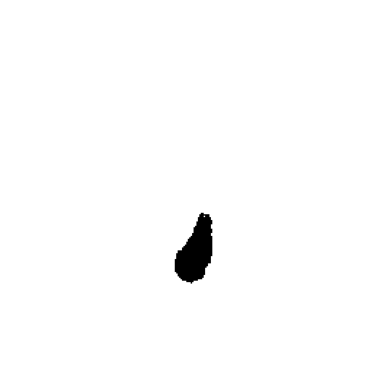

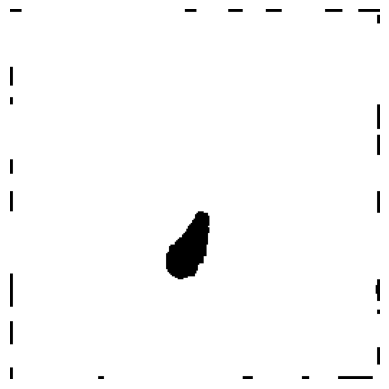

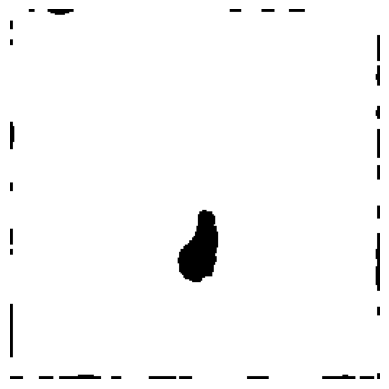

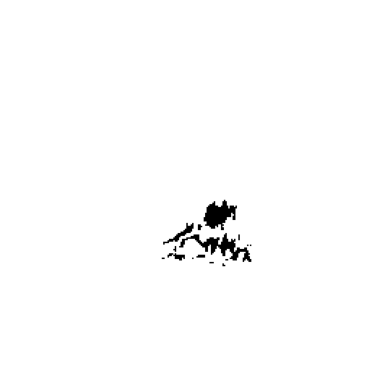

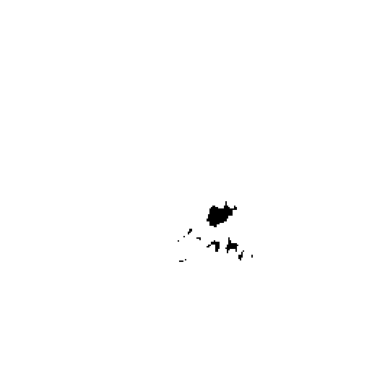

In [ ]:
import matplotlib.pyplot as plt
for i in range(5):
    plt.imshow(new_masks[i].squeeze(), cmap='gray')
    plt.axis('off')
    plt.show()

In [ ]:
!pip install git+https://github.com/tensorflow/examples.git

  Cloning https://github.com/tensorflow/examples.git to /tmp/pip-req-build-mprw9ifa
  Running command git clone --filter=blob:none --quiet https://github.com/tensorflow/examples.git /tmp/pip-req-build-mprw9ifa
  Resolved https://github.com/tensorflow/examples.git to commit b5a8265e0b655001eaa859e7bd8ac9b4e03f3ce8
  Preparing metadata (setup.py) ... done
  Created wheel for tensorflow-examples: filename=tensorflow_examples-0.1763062947.1037077196981023548712530743058318120274395872488-py3-none-any.whl size=300320 sha256=f7b12a43990225694b772bda8b36c3b4db027a388a571c3b9be3ea99700ae97a
  Stored in directory: /tmp/pip-ephem-wheel-cache-emkad736/wheels/ab/17/30/d16d07e2c95286770a9ddcd6f41629ea92b998858c5ee235aa
Successfully built tensorflow-examples


In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow_examples.models.pix2pix import pix2pix
from tqdm import tqdm
import cv2


# Prepare pairs:mask input (1chan)-> image target(3chan)
x_train_mask = train_ulcer.astype('float32')
y_train_img   = train_images.astype('float32')
x_train_mask_3ch = np.repeat(x_train_mask, 3, axis=-1)
# normalize to [-1,1]
x_train_mask = x_train_mask*2.0 - 1.0
y_train_img  = y_train_img*2.0 - 1.0


# small tf dataset
BUFFER=1000
BATCH=8
trainingData = tf.data.Dataset.from_tensor_slices((x_train_mask_3ch, y_train_img)).shuffle(BUFFER).batch(BATCH)

# PixToPix generator and descriminiator
generator = pix2pix.unet_generator(output_channels=3, norm_type='batchnorm')
discriminator = pix2pix.discriminator(norm_type='batchnorm', target=True)

#loss functions:
loss_object =tf.keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real, generated):
  real_loss = loss_object(tf.ones_like(real), real)
  generated_loss = loss_object(tf.zeros_like(generated), generated)
  return real_loss + generated_loss

def generator_loss(disc_generated_output, target, gen_output):
  L1_loss = tf.reduce_mean(tf.abs(target - gen_output))
  GAN_loss = loss_object(tf.ones_like(disc_generated_output), disc_generated_output)
  return GAN_loss + (100 * L1_loss)

generator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

#Trainign step
@tf.function
def train_step(input_mask, target_image):
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        gen_output = generator(input_mask, training=True)
        disc_real = discriminator([input_mask, target_image], training=True)
        disc_generated = discriminator([input_mask, gen_output], training=True)

        gen_loss = generator_loss(disc_generated, target_image, gen_output)
        disc_loss = discriminator_loss(disc_real, disc_generated)

    gradients_gen = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_disc = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_gen, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_disc, discriminator.trainable_variables))

EPOCHS = 50
for epoch in range(EPOCHS):
    for input_mask, target_image in trainingData:
        train_step(input_mask, target_image)
    print(f"Epoch {epoch+1} completed")
generator.save(os.path.join(BASE, "pix2pix_generator.h5"))


Epoch 1 completed
Epoch 2 completed
Epoch 3 completed
Epoch 4 completed
Epoch 5 completed
Epoch 6 completed
Epoch 7 completed
Epoch 8 completed
Epoch 9 completed
Epoch 10 completed
Epoch 11 completed
Epoch 12 completed
Epoch 13 completed
Epoch 14 completed
Epoch 15 completed
Epoch 16 completed
Epoch 17 completed
Epoch 18 completed
Epoch 19 completed
Epoch 20 completed
Epoch 21 completed
Epoch 22 completed
Epoch 23 completed
Epoch 24 completed
Epoch 25 completed
Epoch 26 completed
Epoch 27 completed
Epoch 28 completed
Epoch 29 completed
Epoch 30 completed
Epoch 31 completed
Epoch 32 completed
Epoch 33 completed
Epoch 34 completed
Epoch 35 completed
Epoch 36 completed
Epoch 37 completed
Epoch 38 completed
Epoch 39 completed
Epoch 40 completed
Epoch 41 completed
Epoch 42 completed
Epoch 43 completed
Epoch 44 completed
Epoch 45 completed
Epoch 46 completed
Epoch 47 completed
Epoch 48 completed
Epoch 49 completed


Epoch 50 completed


In [ ]:
PERTURBED_MASKS_PATH = os.path.join(BASE, "perturbed_masks.npy")
SYNTH_IMAGES_DIR = os.path.join(BASE, "synthetic_images")
os.makedirs(SYNTH_IMAGES_DIR, exist_ok=True)

# Loading and normalizing
perturbed_masks = np.load(PERTURBED_MASKS_PATH)  # shape (N,H,W,1)
perturbed_masks_norm = perturbed_masks.astype('float32') * 2.0 - 1.0

In [ ]:
from tqdm import tqdm
import cv2
import numpy as np

for i, mask in tqdm(enumerate(perturbed_masks_norm), total=len(perturbed_masks_norm)):
    mask_input = np.expand_dims(mask, 0)#(1, H, W, 1)
    mask_input_3ch = np.concatenate([mask_input]*3, axis=-1)# (1, H, W, 3)
    gen_img = generator.predict(mask_input_3ch)[0]  # Output shape: (H, W, 3)
    # Converting from [-1,1] back to [0,255]
    gen_img_uint8 = ((gen_img + 1.0) / 2.0 * 255.0).astype(np.uint8)
    # Save as PNG
    cv2.imwrite(
        os.path.join(SYNTH_IMAGES_DIR, f"synthetic_{i}.png"),
        cv2.cvtColor(gen_img_uint8, cv2.COLOR_RGB2BGR)
    )
print(f"Saved {len(perturbed_masks_norm)} synthetic images to {SYNTH_IMAGES_DIR}")



  0%|          | 0/741 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


  0%|          | 1/741 [00:06<1:16:43,  6.22s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


  0%|          | 3/741 [00:06<20:57,  1.70s/it]  

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


100%|█████████▉| 740/741 [01:29<00:00,  8.49it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


100%|██████████| 741/741 [01:29<00:00,  8.24it/s]

Saved 741 synthetic images to /content/drive/MyDrive/corneal_ulcer_dataset/synthetic_images


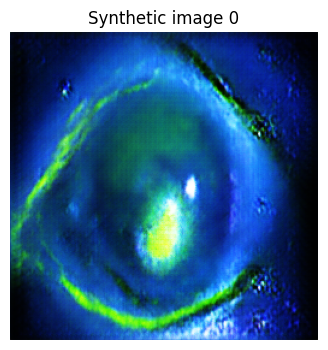

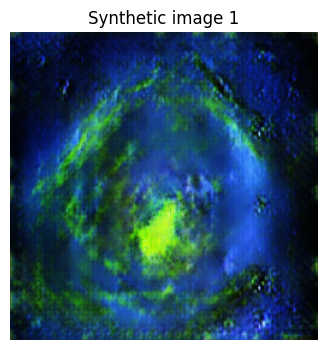

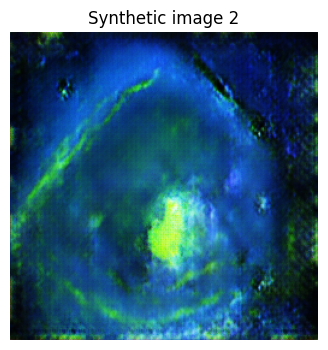

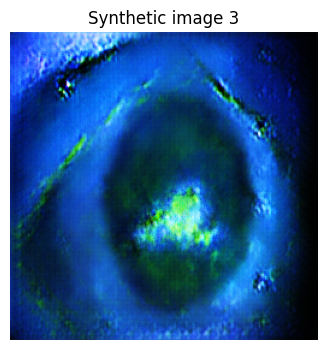

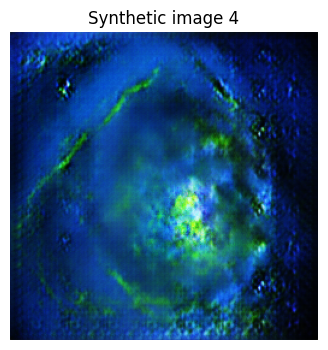

In [ ]:
import matplotlib.pyplot as plt
import os

#visualizing a few pairs
num_to_show = 5
for i in range(num_to_show):
    img_path = os.path.join(SYNTH_IMAGES_DIR, f"synthetic_{i}.png")
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
    plt.figure(figsize=(4,4))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title(f"Synthetic image {i}")
    plt.show()

In [ ]:
import os
PERTURBED_MASKS_PATH = os.path.join(BASE, "perturbed_masks.npy")
print(os.path.exists(PERTURBED_MASKS_PATH))

True


In [ ]:
import os
SYNTH_IMAGES_DIR = os.path.join(BASE, "synthetic_images")

print("Files in synthetic folder:", os.listdir(SYNTH_IMAGES_DIR)[:10])  # first 10 files


Files in synthetic folder: ['synthetic_0.png', 'synthetic_1.png', 'synthetic_2.png', 'synthetic_3.png', 'synthetic_4.png', 'synthetic_5.png', 'synthetic_6.png', 'synthetic_7.png', 'synthetic_8.png', 'synthetic_9.png']


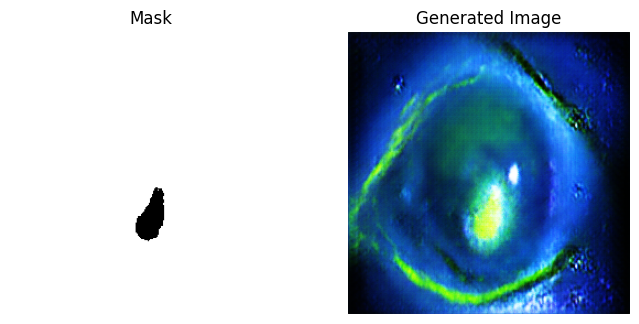

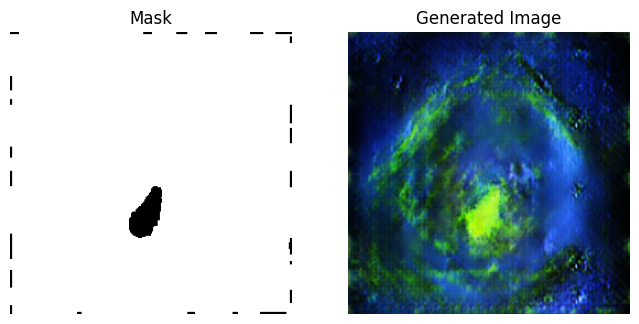

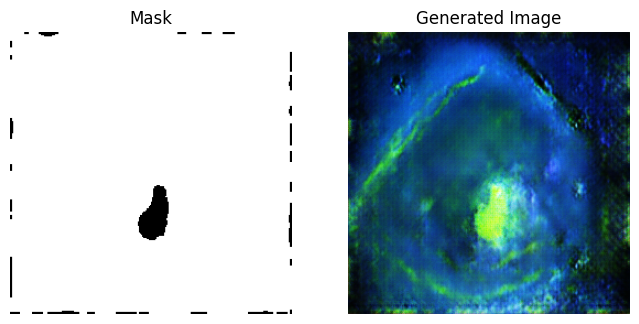

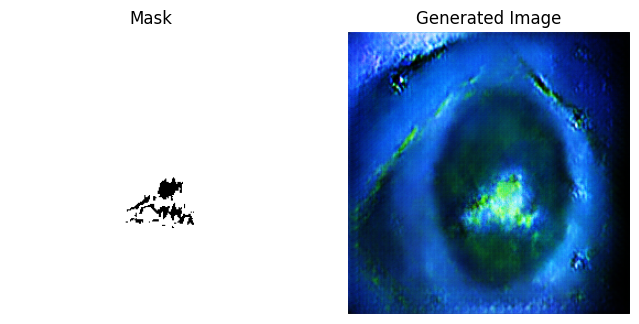

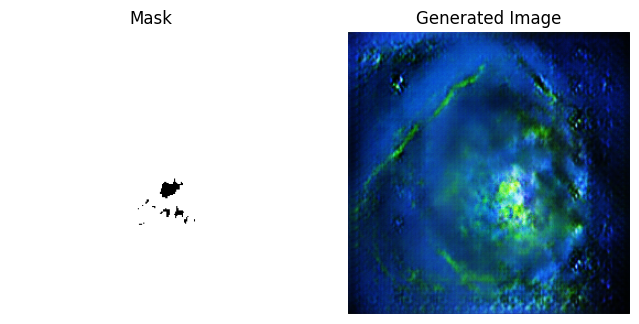

In [ ]:
import matplotlib.pyplot as plt

for i in range(5):  # show first 5
    mask = perturbed_masks[i, :, :, 0]  # original mask
    img = cv2.imread(os.path.join(SYNTH_IMAGES_DIR, f"synthetic_{i}.png"))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1)
    plt.imshow(mask, cmap='gray')
    plt.title("Mask")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(img_rgb)
    plt.title("Generated Image")
    plt.axis('off')

    plt.show()

